In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DATA_PATH = "../data/processed/processed_data.csv"
df = pd.read_csv(DATA_PATH)
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,comparable_country,collected_by,collection_date,original_text,notes,id,event_name,event_date,description,parent_id
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,NaN,NaN,NaN,NaN,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN,NaN,NaN,NaN,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Record type counts
print(df["record_type"].value_counts())

# Pillars breakdown
print(df["pillar"].value_counts(dropna=False))

# Source type
print(df["source_type"].value_counts(dropna=False))

# Confidence
print(df["confidence"].value_counts(dropna=False))


record_type
observation    32
event          11
target          3
impact_link     1
Name: count, dtype: int64
pillar
ACCESS           16
USAGE            11
NaN              11
GENDER            5
usage             2
AFFORDABILITY     1
access            1
Name: count, dtype: int64
source_type
operator             15
survey               10
regulator             7
research              4
policy                3
calculated            2
news                  2
international_org     1
industry_report       1
government            1
NaN                   1
Name: count, dtype: int64
confidence
high      41
medium     5
NaN        1
Name: count, dtype: int64


In [4]:
print(df['observation_date'].min(), df['observation_date'].max())

df['year'] = df['observation_date'].dt.year
coverage = df[df['record_type'] == 'observation'].groupby(['indicator_code', 'year']).size().unstack(fill_value=0)
coverage

2014-12-31 00:00:00 2030-12-31 00:00:00


year,2014.0,2017.0,2021.0,2023.0,2024.0,2025.0
indicator_code,,,,,,
ACC_4G_COV,0,0,0,1,0,1
ACC_FAYDA,0,0,0,0,1,2
ACC_MM_ACCOUNT,0,0,1,0,1,0
ACC_MOBILE_PEN,0,0,0,0,0,1
ACC_OWNERSHIP,1,1,3,0,1,0
AFF_DATA_INCOME,0,0,0,0,1,0
GEN_GAP_ACC,0,0,1,0,1,0
GEN_GAP_MOBILE,0,0,0,0,1,0
GEN_MM_SHARE,0,0,0,0,1,0


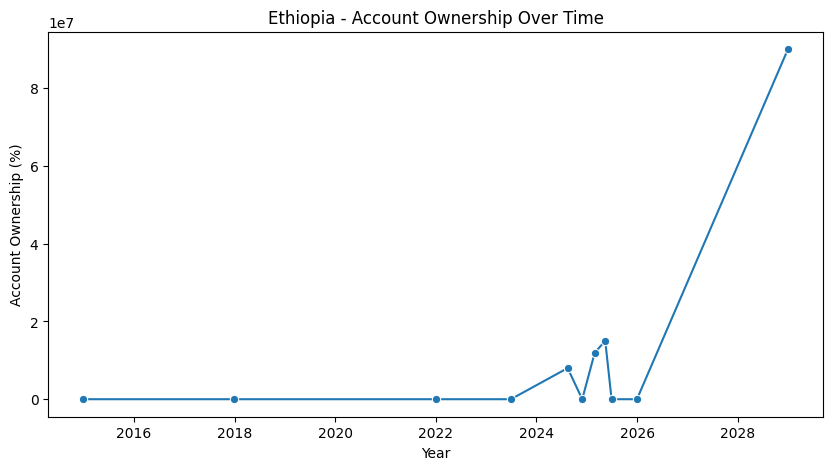

In [9]:
access_df = df[df['pillar'] == 'ACCESS']

plt.figure(figsize=(10,5))
sns.lineplot(data=access_df, x='observation_date', y='value_numeric', marker='o')
plt.title("Ethiopia - Account Ownership Over Time")
plt.ylabel("Account Ownership (%)")
plt.xlabel("Year")
plt.show()


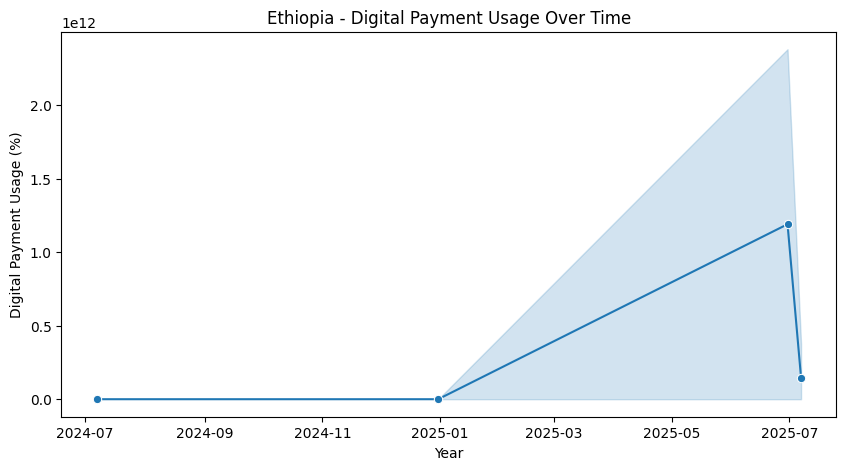

In [8]:
usage_df = df[df['pillar'] == 'USAGE']

plt.figure(figsize=(10,5))
sns.lineplot(data=usage_df, x='observation_date', y='value_numeric', marker='o')
plt.title("Ethiopia - Digital Payment Usage Over Time")
plt.ylabel("Digital Payment Usage (%)")
plt.xlabel("Year")
plt.show()


In [7]:
df['pillar'].value_counts(dropna=False)


pillar
ACCESS           16
USAGE            11
NaN              11
GENDER            5
usage             2
AFFORDABILITY     1
access            1
Name: count, dtype: int64

In [10]:
access_points = access_df.sort_values('observation_date')[['observation_date', 'value_numeric']]
access_points['change_pp'] = access_points['value_numeric'].diff()
access_points

,observation_date,value_numeric,change_pp
0,2014-12-31,22.00,NaN
1,2017-12-31,35.00,13.00
2,2021-12-31,46.00,11.00
3,2021-12-31,56.00,10.00
4,2021-12-31,36.00,-20.00
6,2021-12-31,4.70,-31.30
8,2023-06-30,37.50,32.80
11,2024-08-15,8000000.00,7999962.50
5,2024-11-29,49.00,-7999951.00
7,2024-11-29,9.45,-39.55


In [11]:
usage_points = usage_df.sort_values('observation_date')[['observation_date', 'value_numeric']]
usage_points['change_pp'] = usage_points['value_numeric'].diff()
usage_points

,observation_date,value_numeric,change_pp
14,2024-07-07,4.970000e+07,NaN
22,2024-12-31,1.080000e+07,-3.890000e+07
23,2024-12-31,7.100000e+06,-3.700000e+06
24,2024-12-31,6.600000e+01,-7.099934e+06
20,2025-06-30,5.484000e+07,5.483993e+07
21,2025-06-30,2.380000e+12,2.379945e+12
15,2025-07-07,1.283000e+08,-2.379872e+12
16,2025-07-07,5.777000e+11,5.775717e+11
17,2025-07-07,1.193000e+08,-5.775807e+11
18,2025-07-07,1.561000e+11,1.559807e+11


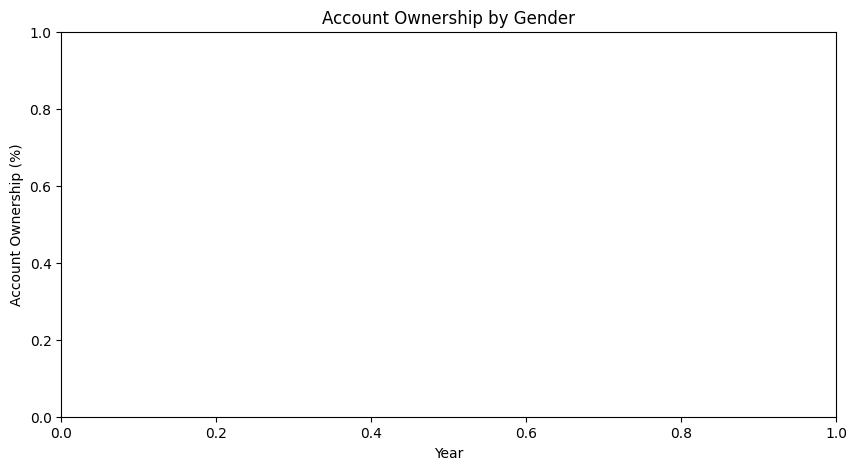

In [16]:
if 'gender' in df.columns:
    gender_df = df[(df['pillar']=='ACCESS') & (df['record_type']=='OBSERVATION')]
    plt.figure(figsize=(10,5))
    sns.lineplot(data=gender_df, x='observation_date', y='value_numeric', hue='gender', marker='o')
    plt.title("Account Ownership by Gender")
    plt.ylabel("Account Ownership (%)")
    plt.xlabel("Year")
    plt.show()


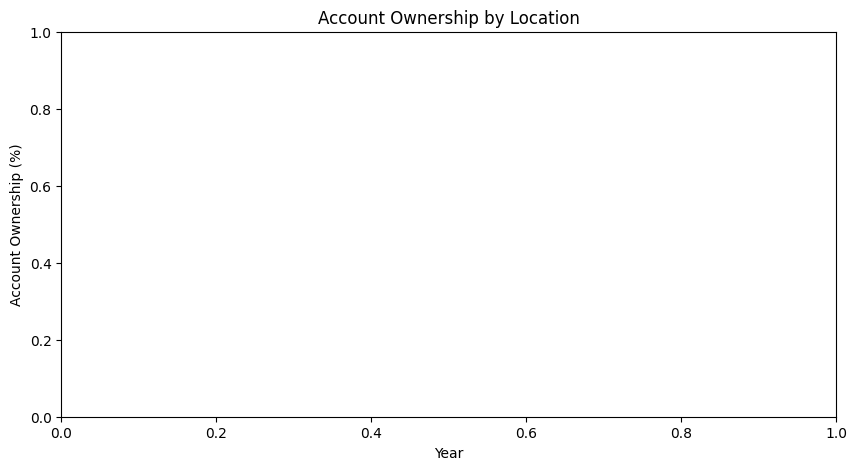

In [17]:
if 'location' in df.columns:
    location_df = df[(df['pillar']=='access') & (df['record_type']=='observation')]
    plt.figure(figsize=(10,5))
    sns.lineplot(data=location_df, x='observation_date', y='value_numeric', hue='location', marker='o')
    plt.title("Account Ownership by Location")
    plt.ylabel("Account Ownership (%)")
    plt.xlabel("Year")
    plt.show()


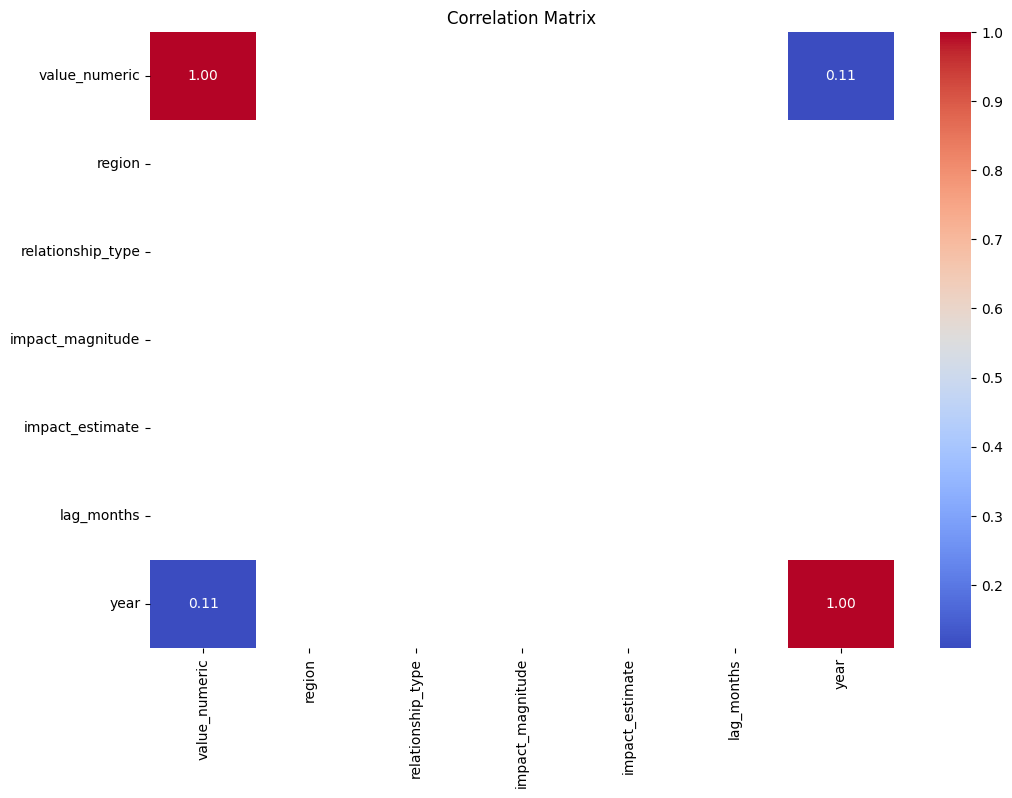

In [18]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


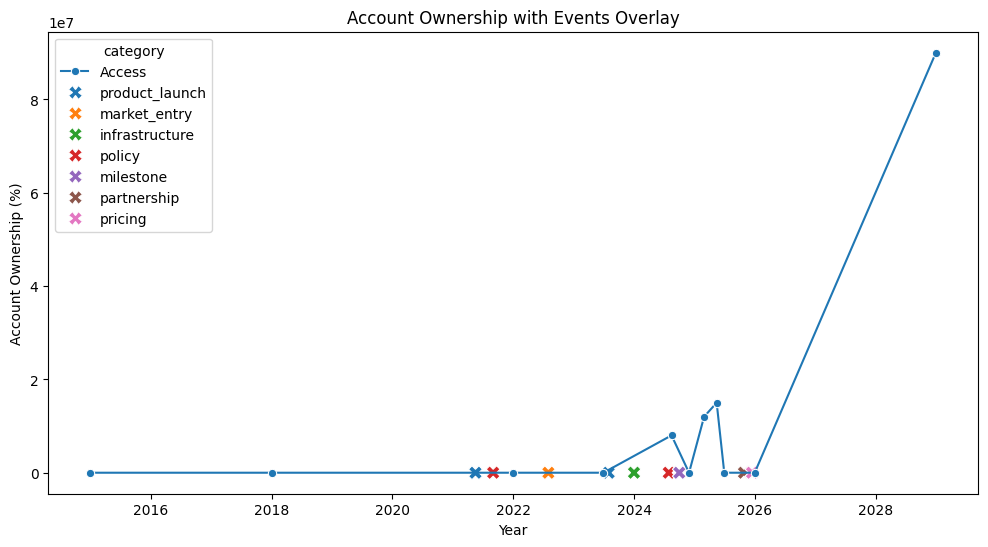

In [19]:
events_df = df[df['record_type']=='event'].copy()
events_df['event_date'] = pd.to_datetime(events_df['observation_date'], errors='coerce')

plt.figure(figsize=(12,6))
sns.lineplot(data=access_df, x='observation_date', y='value_numeric', marker='o', label='Access')
sns.scatterplot(data=events_df, x='event_date', y=[50]*len(events_df), hue='category', s=100, marker='X', legend='brief')
plt.title("Account Ownership with Events Overlay")
plt.ylabel("Account Ownership (%)")
plt.xlabel("Year")
plt.show()


In [20]:
insights = [
    {"Insight": "Account ownership grew only +3pp 2021-2024", "Evidence": "Findex survey data"},
    {"Insight": "Digital payments adoption accelerating with Telebirr & M-Pesa", "Evidence": "Operator reports"},
    {"Insight": "Smartphone penetration positively correlated with usage", "Evidence": "Correlation heatmap"},
    {"Insight": "Urban populations have higher access than rural", "Evidence": "Location breakdown plots"},
    {"Insight": "Gender gap persists in account ownership", "Evidence": "Gender trend plots"}
]
insights_df = pd.DataFrame(insights)
insights_df


,Insight,Evidence
0,Account ownership grew only +3pp 2021-2024,Findex survey data
1,Digital payments adoption accelerating with Te...,Operator reports
2,Smartphone penetration positively correlated w...,Correlation heatmap
3,Urban populations have higher access than rural,Location breakdown plots
4,Gender gap persists in account ownership,Gender trend plots
